**Project Title:** Digital media consumption and market trends\
**Author:** Maverick Luke \
**Date:** April 23rd, 2025 

# Imports and Constants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
from datetime import datetime, timedelta
from time import sleep
import yfinance as yf
import praw
import re
import statsmodels.api as sm
from scipy import stats
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [2]:
# Constants for retrieving data from APIs (not necessary to run the code)
# These constants are used to store the API keys and other sensitive information
with open('tmdb_api_key.txt', 'r') as file:
    for line in file:
        clean_line = line.strip()
        if clean_line:
            API_KEY = clean_line # your api key (can be obtained from https://github.com/rickylawson/freekeys/blob/master/index.js)
            break

with open('reddit_client.txt', 'r') as file:
    lines = file.readlines()
    CLIENT_ID = lines[0].strip() # your client id 
    CLIENT_SECRET = lines[1].strip() # your client secret
    USER_AGENT = lines[2].strip() # python:JSC370.project:v1.0 (by /u/YOUR_REDDIT_USERNAME)

# Introduction

The streaming media landscape has evolved dramatically in recent years, with platforms like Netflix and Disney+ competing intensely for subscribers. Original content has become a primary differentiator in this competition, with platforms investing billions in developing exclusive shows and movies. Meanwhile, social media platforms like Reddit serve as immediate indicators of audience reception, potentially signaling a release's success or failure. This intersection of streaming content strategies and social media engagement raises an important question for investors: How do major content releases on these platforms affect their stock market performance, and can social media metrics serve as leading indicators for these market movements?

## Research Question
This project addresses the question: **How do major streaming content releases on Netflix and Disney+ affect their respective stock prices in the short term, and does social media engagement correlate with these market movements?** \
Specifically, we analyze:

1. Whether stock prices show abnormal returns in the 3-day window following content releases
2. Whether Reddit engagement metrics correlate with stock price movements
3. Is the sentiment of Reddit comments about a movie (positive/negative) associated with upward/downward movement in stock price?
4. Is there a lagged relationship between Reddit engagement and provider stock returns (e.g., 1-day, 3-day, 7-day lag)?

# Methods

The study combines data from three distinct sources to examine relationships between streaming content releases, stock market performance, and social media engagement:

- Streaming Content Data: **The Movie Database (TMDB) API** was used to collect information about Netflix and Disney+ releases, including release dates, popularity scores, and genres. Both TV shows and movies were included to ensure a sufficient sample size.
- Stock Market Data: Financial data for Netflix (NFLX), Disney (DIS), and the S&P 500 index was collected using the Yahoo Finance API via the Python **yfinance** package. Daily closing prices, trading volume, and other metrics were gathered for the period from September 2024 to March 2025.
- Social Media Engagement Data: Reddit's API was accessed using the Python **praw** library to collect post and comment data related to each content release. Data was collected from relevant subreddits including r/television, r/netflix, r/DisneyPlus, r/streaming.

## API Implementation
(*Skip to `Read existing CSV files` if the dataframes are available in CSVs*) \

The following code demonstrates how data was collected from each API source: (Note that the API calls take some time and requires API keys (for TMDB) and client id and client secret (for Reddit praw). To improve efficiency, I’ve saved the datasets as CSV files for quicker retrieval. The retrieval code is located right below the API calls functions)

In [16]:
# Function to get the top releases for a given streaming provider
# The function fetches the top TV shows released on the specified streaming platform
def get_top_releases(provider_id, start_date, end_date, api_key = API_KEY):
    base_url_tv = "https://api.themoviedb.org/3/tv/popular"
    base_url_movie = "https://api.themoviedb.org/3/movie/popular"
    
    tv_results = []
    movie_results = []

    page_tv = 1
    page_movie = 1
    max_page = 30
    
    while True:
        params_tv = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'first_air_date.gte': start_date,
            'first_air_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_tv
        }
        params_movie = {
            'api_key': api_key,
            'with_watch_providers': provider_id,
            'watch_region': 'US',
            'primary_release_date.gte': start_date,
            'primary_release_date.lte': end_date,
            'sort_by': 'popularity.desc',
            'page': page_movie
        }

        if page_tv < max_page: 
            response_tv = requests.get(base_url_tv, params_tv)
            data = response_tv.json()
            if 'results' in data:
                tv_results.extend(data['results'])
            page_tv += 1

        if page_movie < max_page:
            response_movie = requests.get(base_url_movie, params_movie)
            data = response_movie.json()
            if 'results' in data:
                movie_results.extend(data['results'])
            page_movie += 1        

        if page_tv >= max_page and page_movie >= max_page:
            break

        sleep(0.5)  
    
    for item in tv_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['content-type'] = 'TV Show'
    
    for item in movie_results:
        item['provider'] = 'Netflix' if provider_id == 8 else 'Disney+'
        item['provider_id'] = provider_id
        item['first_air_date'] = item['release_date']
        item['name'] = item['title']
        item['content-type'] = 'Movie'

    return tv_results, movie_results

def get_all_genre_info():
    genre_tv_url = f"https://api.themoviedb.org/3/genre/tv/list"
    genre_movie_url = f"https://api.themoviedb.org/3/genre/movie/list"
    params = {
        'api_key': API_KEY
    }
    response_tv = requests.get(genre_tv_url, params)
    response_movie = requests.get(genre_movie_url, params)
    
    data_tv = response_tv.json()
    data_movie = response_movie.json()

    all_genres = data_tv['genres'] + data_movie['genres']
    all_genres_dict = {genre['id']: genre['name'] for genre in all_genres}

    return all_genres_dict

# Function to get genre information for a given genre ID
# The function returns a list of genre names for the given genre IDs
def get_genre_info(genre_ids, genres_dict):
    genres = []
    for genre_id in genre_ids:
        genre_name = genres_dict.get(genre_id)
        if genre_name:
            genres.append(genre_name)
    return genres


# Get genre information for TV shows and movies
all_genres_dict = get_all_genre_info()
all_genres = list(all_genres_dict.values())

# Fetch top releases for Netflix and Disney+ from 2000 to now
start_date = "2000-01-01" 
end_date = str(datetime.now().strftime("%Y-%m-%d"))

netflix_releases_tv, netflix_releases_movie = get_top_releases(8, start_date, end_date) # 8 is the ID for Netflix
disney_releases_tv, disney_releases_movie = get_top_releases(337, start_date, end_date) # 337 is the ID for Disney+ 

# Combine the results into a single DataFrame
releases_df_tv = pd.DataFrame(netflix_releases_tv + disney_releases_tv) 
releases_df_movie = pd.DataFrame(netflix_releases_movie + disney_releases_movie)
releases_df = pd.concat([releases_df_tv, releases_df_movie], ignore_index=True)

# Add genre information to the DataFrame
for genre in all_genres_dict.keys():
    releases_df[all_genres_dict[genre]] = releases_df['genre_ids'].apply(lambda x: 1 if genre in x else 0)

releases_df = releases_df[[
    'id', 'name', 'first_air_date', 'popularity', 
    'vote_average', 'vote_count', 'provider', 'provider_id', 'content-type'] + list(all_genres_dict.values())]

releases_df['release_date'] = pd.to_datetime(releases_df['first_air_date'])
releases_df['ticker'] = releases_df['provider'].map({
    'Netflix': 'NFLX',
    'Disney+': 'DIS'
})


In [17]:
# Filter the DataFrame based on popularity and vote count to get the top releases
min_popularity = 30
min_votes = 1000

print("Before filtering:")
print(f"Number of releases: {len(releases_df)}")
print(f"Date range: {releases_df['release_date'].min()} to {releases_df['release_date'].max()}")
print(f"Top 5 releases:\n{releases_df.head()}")

print("After filtering:")
releases_df = releases_df[
        (releases_df["popularity"] > min_popularity) &
        (releases_df["vote_count"] > min_votes)
    ]
print(f"Number of releases: {len(releases_df)}")
print(f"Date range: {releases_df['release_date'].min()} to {releases_df['release_date'].max()}")
print(f"Top 5 releases:\n{releases_df.head()}")

Before filtering:
Number of releases: 2320
Date range: 1933-07-13 00:00:00 to 2025-11-05 00:00:00
Top 5 releases:
      id                                     name first_air_date  popularity  \
0  13945            Gute Zeiten, schlechte Zeiten     1992-05-11    705.3679   
1   2261  The Tonight Show Starring Johnny Carson     1962-10-01    584.9169   
2  45789                          Sturm der Liebe     2005-09-26    574.8943   
3  22980  Watch What Happens Live with Andy Cohen     2009-07-16    521.1378   
4  63770       The Late Show with Stephen Colbert     2015-09-08    503.1590   

   vote_average  vote_count provider  provider_id content-type  \
0         5.784          37  Netflix            8      TV Show   
1         7.474          77  Netflix            8      TV Show   
2         6.044          34  Netflix            8      TV Show   
3         5.000          63  Netflix            8      TV Show   
4         6.400         301  Netflix            8      TV Show   

   Actio

In [25]:
# Function to get the stock data for the specified tickers and date range
# The function fetches the stock data for the specified tickers from Yahoo Finance
def get_stock_data(tickers, start_date, end_date):
    # Add buffer to start and end dates
    start_buffer = (pd.to_datetime(start_date) - timedelta(days=14)).strftime('%Y-%m-%d')
    end_buffer = (pd.to_datetime(end_date) + timedelta(days=14)).strftime('%Y-%m-%d')
    
    data = yf.download(tickers, start=start_buffer, end=end_buffer, auto_adjust=False)
    
    # Stack the column indices to create a single level of column labels
    df = data.stack(level=1).reset_index()
    df.columns = ['Date', 'Ticker', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

    df = df.sort_values(['Ticker', 'Date'])
    # Calculate daily returns for each stock (in percentage)
    df['Daily_Return'] = df.groupby('Ticker')['Adj Close'].pct_change() * 100
    return df

tickers = ['NFLX', 'DIS', '^GSPC']  # Netflix, Disney, and S&P 500
start_date = start_date 
end_date = end_date

stock_data = get_stock_data(tickers, start_date, end_date)
# Replace the ticker symbol for S&P 500 with 'SPY'
stock_data.loc[stock_data['Ticker'] == '^GSPC', 'Ticker'] = 'SPY'

[*********************100%***********************]  3 of 3 completed


In [26]:
# Calculate abnormal returns for each release
def calculate_abnormal_returns(releases, stock_data):
    results = []
    
    for _, release in releases.iterrows():
        ticker = release['ticker']
        release_date = release['release_date']
        
        start_date = release_date
        # Use a 3-day window after the release date to minimize noise
        end_date = release_date + timedelta(days=3)
        
        # Get stock data for this window
        stock_window = stock_data[
            (stock_data['Ticker'] == ticker) & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        # Get market data (S&P 500) for the same window
        market_window = stock_data[
            (stock_data['Ticker'] == 'SPY') & 
            (stock_data['Date'] >= start_date) & 
            (stock_data['Date'] <= end_date)
        ]
        
        if len(stock_window) > 0 and len(market_window) > 0:
            # Calculate cumulative returns
            if len(stock_window) > 1:
                # Use first and last prices
                first_price = stock_window.iloc[0]['Adj Close']
                last_price = stock_window.iloc[-1]['Adj Close']
                stock_return = (last_price - first_price) / first_price * 100
            else:
                stock_return = stock_window.iloc[0]['Daily_Return']
            
            if len(market_window) > 1:
                first_market = market_window.iloc[0]['Adj Close']
                last_market = market_window.iloc[-1]['Adj Close']
                market_return = (last_market - first_market) / first_market * 100
            else:
                market_return = market_window.iloc[0]['Daily_Return']
            
            abnormal_return = stock_return - market_return
            
            result = release.copy()
            result['stock_return'] = stock_return
            result['market_return'] = market_return
            result['abnormal_return'] = abnormal_return
            results.append(result)
    
    return pd.DataFrame(results)

# Change the date to the correct format
releases_df['release_date'] = pd.to_datetime(releases_df['release_date'])
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

returns_df = calculate_abnormal_returns(releases_df, stock_data)

In [24]:
# Function to retrieve engagement data from Reddit for a given movie title and release date
# The function searches for posts related to the movie on specific subreddits
# Caution: This function makes multiple requests to the Reddit API and may take some time to run
def get_reddit_engagement(title, release_date, reddit_client, is_movie=True, is_netflix=True, comment_limit=10):
    if not isinstance(release_date, datetime):
        release_date = pd.to_datetime(release_date)
    
    start_date = release_date - timedelta(days=14)
    end_date = release_date + timedelta(days=14)
    
    search_queries = [
        f'{title} discussion',
    ] 

    # Remove subtitle from the title (if present)
    clean_title = re.sub(r'[:\-–—].*$', '', title).strip()
    if clean_title != title:
        search_queries.append(f'"{clean_title}"')
    
    subreddits = []
    if is_movie:
        subreddits.append('movies')
    else: 
        subreddits.append('television')
    if is_netflix:
        subreddits.append('netflix')
        subreddits.append('NetflixBestOf')
    else:
        subreddits.append('DisneyPlus')
    
    all_posts = []

    for subreddit_name in subreddits:
        subreddit = reddit_client.subreddit(subreddit_name)
        for search_query in search_queries: 
            # Search for posts in the subreddit
            after_date = int(start_date.timestamp())
            before_date = int(end_date.timestamp())
            for post in subreddit.search(search_query, sort='relevance', limit=300, params={'after': after_date, 'before': before_date}):
                post_date = datetime.fromtimestamp(post.created_utc)

                if (start_date <= post_date <= end_date and
                    title.lower() in post.title.lower()):

                    submission = post
                    submission.comments.replace_more(limit=0)
                    top_comments = [{
                        "body": comment.body,
                        "controversiality": getattr(comment, "controversiality", 0)
                    } for comment in submission.comments[:comment_limit]]

                    all_posts.append({
                        'title': post.title,
                        'subreddit': subreddit_name,
                        'date': post_date,
                        'score': post.score,
                        'num_comments': post.num_comments,
                        'upvote_ratio': post.upvote_ratio,
                        'post_id': post.id,
                        'post_url': post.url,
                        'top_comments': top_comments,
                        'text': getattr(post, "selftext", ""),
                    })
    return all_posts    

analyzer = SentimentIntensityAnalyzer()

# Function to summarize engagement data from Reddit posts
# The function calculates various sentiment metrics based on the posts and comments
def get_reddit_engagement_summary(all_posts, 
                                  alpha=1.0, 
                                  beta=1.0, 
                                  gamma=1.0, 
                                  delta=1.0, 
                                  x=1.0, 
                                  y=1.0, 
                                  z=1.0, 
                                  include_engagement_score=True, 
                                  num_comments=10):
    # Initialize variables to store scores and metrics
    # all_scores: List to store all sentiment scores
    # weighted_scores: List to store weighted sentiment scores
    # engagement_scores: List to store engagement scores
    # controversial_count: Counter for the number of controversial comments
    all_scores = []
    weighted_scores = []
    engagement_scores = []
    controversial_count = 0

    has_engagement = False
    if len(all_posts) > 0:
        has_engagement = True
        for post in all_posts:
            post_text = f"{post.get('title', '')} {post.get('text', '')}"
            post_sentiment = analyzer.polarity_scores(post_text)["compound"]

            # Base metrics
            score = post.get("score", 0)
            upvote_ratio = post.get("upvote_ratio", 0.5)
            num_comments = post.get("num_comments", 0)

            # Normalize metrics
            # Using log1p to avoid issues with zero values
            score_norm = np.log1p(score)
            comments_norm = np.log1p(num_comments)

            # Weighted sentiment for post
            w_post = post_sentiment * (1 + alpha * (score_norm) + beta * upvote_ratio + gamma * (comments_norm))
            all_scores.append(post_sentiment)
            weighted_scores.append(w_post)

            # Analyze top comments
            for comment in post.get("top_comments", []):
                text = comment.get("body", "")
                if not text.strip():
                    continue
                sentiment = analyzer.polarity_scores(text)["compound"]
                w_comment = sentiment * (1 + alpha * (score_norm) + beta * upvote_ratio + gamma * (comments_norm))
                all_scores.append(sentiment)
                weighted_scores.append(w_comment)
                controversial_count += comment.get("controversiality", 0)

            # Calculate engagement score 
            if include_engagement_score:
                engagement_score = (
                    x * score_norm +
                    y * comments_norm +
                    z * upvote_ratio
                )
                engagement_scores.append(engagement_score)
            
    summary = {
        "has_engagement": has_engagement,
        "n_texts": len(all_scores),
        "avg_sentiment": np.mean(all_scores) if all_scores else np.nan,
        "std_sentiment": np.std(all_scores) if all_scores else np.nan,
        "min_sentiment": np.min(all_scores) if all_scores else np.nan,
        "max_sentiment": np.max(all_scores) if all_scores else np.nan,
        "avg_weighted_sentiment": np.mean(weighted_scores) if weighted_scores else np.nan,
        "max_weighted_sentiment": np.max(weighted_scores) if weighted_scores else np.nan,
    }
    expected_total_comments = len(all_posts) * num_comments
    controversial_norm = controversial_count / expected_total_comments if expected_total_comments > 0 else 0 
    if include_engagement_score:
        summary["engagement_score"] = round(np.sum(engagement_scores) + delta * controversial_norm, 3)

    return summary


reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

engagement_data = []
minimal_posts = []

# releases_df_sample = releases_df.sample(min(30, len(releases_df)), random_state=100)

for index, row in releases_df.iterrows():
    title = row['name']
    release_date = row['release_date']
    is_movie = row['content-type'] == 'Movie'
    is_netflix = row['provider'] == 'Netflix'

    engagement = get_reddit_engagement(title, release_date, reddit, is_movie, is_netflix)
    minimal_posts.extend([{
        "name": title,
        "release_date": release_date,
        "post_id": post["post_id"],
        "title": post["title"],
        "subreddit": post["subreddit"],
        "url": post["post_url"]
    } for post in engagement])

    engagement_summary = get_reddit_engagement_summary(engagement)
    engagement_summary["name"] = title
    engagement_summary["release_date"] = release_date
    engagement_data.append(engagement_summary)

    sleep(2)
        
engagement_df = pd.DataFrame(engagement_data)
minimal_posts_df = pd.DataFrame(minimal_posts)

In [27]:
print(engagement_df.head())
# Summary of engagement data
print("Engagement Data Summary:")
print(engagement_df.describe())
print("Release Data Summary:")
print(releases_df.describe())

   has_engagement  n_texts  avg_sentiment  std_sentiment  min_sentiment  \
0            True       38       0.240595       0.525079        -0.8442   
1           False        0            NaN            NaN            NaN   
2           False        0            NaN            NaN            NaN   
3            True       11       0.245573       0.531898        -0.7906   
4            True       11       0.327118       0.467909        -0.5271   

   max_sentiment  avg_weighted_sentiment  max_weighted_sentiment  \
0         0.9906                2.198142               16.388170   
1            NaN                     NaN                     NaN   
2            NaN                     NaN                     NaN   
3         0.8807                2.550323                9.146249   
4         0.9649                3.891714               11.479383   

   engagement_score                               name release_date  
0            41.623                     The Last of Us   2023-01-15  


In [31]:
# TODO: Delete this
reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

release_date_monsters = pd.to_datetime('2024-09-19')

start_date = release_date_monsters - timedelta(days=14)
end_date = release_date_monsters + timedelta(days=14)

i = 0
for submission in reddit.subreddit("movies").search("Monsters movie", sort="relevance", limit=1000):
    if i > 10:
        break
    if submission.created_utc >= start_date.timestamp() and submission.created_utc <= end_date.timestamp():
        print('-', submission.title)
        print(' ', datetime.fromtimestamp(submission.created_utc))
        print(' ', submission.subreddit.display_name)
        i += 1

- 'The Apprentice' - Review Thread
  2024-09-11 12:23:14
  movies


## Content Data Preprocessing
The data structures for TV shows and movies were standardized to ensure consistency. For TV shows, the field first_air_date was renamed to release_date to align with the naming convention used for movies. Additionally, a content_type field was introduced to clearly distinguish between movies and TV shows, making it easier to organize the data. This standardization simplifies comparisons and ensures a unified format across different types of content. Genre information is retrieved and one-hot encoded to enable analysis by genre. Retrieved releases are sorted by popularity and filtered to include only those with at least 1000 votes. 

## Stock Data Preprocessing
In the stock data preprocessing phase, two key calculations were performed to analyze stock performance: return calculation and market adjustment. 
First, daily returns were computed as the percentage change in the adjusted closing price from the previous day, providing insight into short-term price movements. 
To isolate company-specific movements from broader market trends, abnormal returns were calculated. This was achieved by subtracting the market return (represented by the S&P 500 index as the benchmark) from the stock return. The formula used was:
**abnormal_return = stock_return - market_return**.
Finally, event windows were defined to examine the impact of content releases on stock performance. A 3-day post-release window (from the release day to two days after) was specifically analyzed to capture short-term stock reactions to the release of new content.

## Social Media Data Processing
Reddit posts were filtered to a 28-day window (14 days before and after each release) to capture audience engagement around content launches. Posts are filtered by relevance and cleaned titles to improve matching. For each post, metadata (e.g., score, upvote ratio, comment count) and top comments are collected. Sentiment analysis is applied to both posts and comments using VADER, and sentiment scores are weighted by engagement metrics. The final output includes summary statistics such as **average sentiment**, **weighted sentiment**, and a custom **engagement score** incorporating upvotes, comments, and controversiality. 

## Data Integration
The processed datasets were merged based on content title and release date. The final integrated dataset included the following key variables:
- Content information: title, release date, platform, popularity, genre, content type
- Stock performance: abnormal returns across different time windows
- Social media engagement: average sentiment, weighted sentiment, engagement score

## Tools and Libraries Used
The analysis was conducted using the following Python libraries:

- Data Collection: requests, yfinance, praw
- Data Processing: pandas, numpy
- Sentiment analysis: VADER
- Time Series Handling: datetime
- Visualization: matplotlib, seaborn

We save each dataset into csv files so that anytime we need the data, we can just read from them.

In [28]:
# Saving the data to a CSV file for convenience
releases_df.to_csv('top_releases.csv', index=False)
stock_data.to_csv('stock_data.csv', index=False)
returns_df.to_csv('abnormal_returns.csv', index=False)
engagement_df.to_csv('reddit_engagement.csv', index=False)
minimal_posts_df.to_csv('reddit_engagement_minimal.csv', index=False)

## Read existing CSV files

In [ ]:
# Read the data from the CSV files (not necessary to run the code if the data is already available)
releases_df = pd.read_csv('top_releases.csv')
stock_data = pd.read_csv('stock_data.csv')
returns_df = pd.read_csv('abnormal_returns.csv')
engagement_df = pd.read_csv('reddit_engagement.csv')
minimal_posts_df = pd.read_csv('reddit_engagement_minimal.csv')

all_genres = list(releases_df.columns[9:-2])

## Exploratory Data Analysis

In [4]:
# Exploratory Data Analysis
release_df_summary = releases_df.describe()
stock_data_summary = stock_data.describe()
returns_df_summary = returns_df.describe()  
engagement_df_summary = engagement_df.describe()

print(f"Columns in the datasets:")
print("Releases Data:")
display(release_df_summary)
print("Stock Data:")
display(stock_data_summary)
print("Abnormal Returns Data:")
display(returns_df_summary)
print("Reddit Engagement Data:")
display(engagement_df_summary)



Columns in the datasets:
Releases Data:


,id,popularity,vote_average,vote_count,provider_id,Action & Adventure,Animation,Comedy,Crime,Documentary,...,Adventure,Fantasy,History,Horror,Music,Romance,Science Fiction,TV Movie,Thriller,War
count,3.360000e+02,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,...,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,6.760844e+05,3.063289,6.219107,319.851190,141.166667,0.101190,0.163690,0.252976,0.113095,0.229167,...,0.077381,0.047619,0.020833,0.032738,0.062500,0.041667,0.053571,0.005952,0.077381,0.011905
std,4.725779e+05,3.629484,2.542967,796.616379,161.729151,0.302031,0.370546,0.435366,0.317182,0.420924,...,0.267593,0.213276,0.143039,0.178216,0.242422,0.200124,0.225506,0.077036,0.267593,0.108619
min,8.245200e+04,0.001000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.425252e+05,0.530250,6.000000,6.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.263585e+05,3.611000,6.953000,83.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.180630e+06,3.868250,7.700000,233.750000,337.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.448322e+06,39.971000,10.000000,6880.000000,337.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Stock Data:


,Adj Close,Close,High,Low,Open,Volume,Daily_Return
count,783.000000,783.000000,783.000000,783.000000,783.000000,7.830000e+02,780.000000
mean,2110.840678,2111.041199,2121.932656,2098.910319,2110.743622,1.330336e+09,0.134300
std,2436.024229,2435.858875,2445.244021,2425.072547,2435.885197,1.923029e+09,1.473354
min,85.222374,85.599998,86.250000,83.910004,85.150002,1.354200e+06,-9.513179
25%,111.603321,112.364998,113.185001,111.120003,111.939999,3.693350e+06,-0.576962
50%,674.070007,674.070007,682.710022,665.109985,673.440002,9.028600e+06,0.092269
75%,5205.074951,5205.074951,5227.469971,5182.229980,5205.354980,3.548540e+09,0.817651
max,6118.709961,6118.709961,6128.180176,6088.740234,6121.430176,8.223220e+09,11.498896


Abnormal Returns Data:


,id,popularity,vote_average,vote_count,provider_id,Action & Adventure,Animation,Comedy,Crime,Documentary,...,Horror,Music,Romance,Science Fiction,TV Movie,Thriller,War,stock_return,market_return,abnormal_return
count,3.360000e+02,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,...,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,6.760844e+05,3.063289,6.219107,319.851190,141.166667,0.101190,0.163690,0.252976,0.113095,0.229167,...,0.032738,0.062500,0.041667,0.053571,0.005952,0.077381,0.011905,0.285475,0.183921,0.101553
std,4.725779e+05,3.629484,2.542967,796.616379,161.729151,0.302031,0.370546,0.435366,0.317182,0.420924,...,0.178216,0.242422,0.200124,0.225506,0.077036,0.267593,0.108619,2.331453,0.991786,2.186445
min,8.245200e+04,0.001000,0.000000,0.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.513179,-3.324288,-9.647522
25%,2.425252e+05,0.530250,6.000000,6.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.847895,-0.307532,-0.957797
50%,5.263585e+05,3.611000,6.953000,83.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013241,0.252133,-0.137236
75%,1.180630e+06,3.868250,7.700000,233.750000,337.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.184512,0.852151,0.924810
max,1.448322e+06,39.971000,10.000000,6880.000000,337.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.951882,3.679563,15.846439


Reddit Engagement Data:


,total_posts,total_comments,total_score,avg_upvote_ratio
count,336.000000,336.000000,336.000000,336.000000
mean,7.363095,702.139881,1977.812500,0.434504
std,15.932479,2083.705384,6863.175132,0.362039
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,2.000000,22.500000,12.500000,0.574545
75%,8.000000,359.500000,529.250000,0.758333
max,176.000000,22197.000000,59363.000000,1.000000


In [10]:
# TODO: Delete this section
# Print rows with maximum values for each column in the engagement DataFrame
print("Rows with maximum values for each column in the engagement DataFrame:")
for column in engagement_df.columns[1:]:
    max_value = engagement_df[column].max()
    max_rows = engagement_df[engagement_df[column] == max_value]
    print(f"Max value for {column}: {max_value}")
    print(max_rows)
    print("\n")

Rows with maximum values for each column in the engagement DataFrame:
Max value for total_comments: 22197
    total_posts  total_comments  total_score  avg_upvote_ratio  \
22          176           22197        47553          0.644943   

              name release_date  
22  3 Body Problem   2024-03-21  


Max value for total_score: 59363
    total_posts  total_comments  total_score  avg_upvote_ratio      name  \
23           70            8900        59363          0.749429  Monsters   

   release_date  
23   2024-09-19  


Max value for avg_upvote_ratio: 1.0
     total_posts  total_comments  total_score  avg_upvote_ratio  \
48             1               5            7               1.0   
264            1               3            2               1.0   

                   name release_date  
48             The Cage   2024-11-08  
264  The Beautiful Game   2024-03-22  


Max value for name: ＜JUNG KOOK: I AM STILL＞ THE ORIGINAL
     total_posts  total_comments  total_score  avg_up

In [5]:
# Remove the rows with null values in the stock data
clean_stock_data = stock_data.dropna()

Daily return calculations require both the current and previous day's adjusted close values. Each of our 3 tickers has one row where the previous day's data is unavailable, resulting in a null value for the daily return on that specific row. This is an expected consequence of our finite dataset rather than an error in the data.

In [ ]:
# Merge returns_df and engagement_df on the 'title' and 'release_date' columns
merged_data = pd.merge(returns_df, engagement_df, on=['name', 'release_date'], how='inner')
# Select only the relevant columns
merged_data = merged_data.drop(columns=['id', 'first_air_date', 'provider_id'])

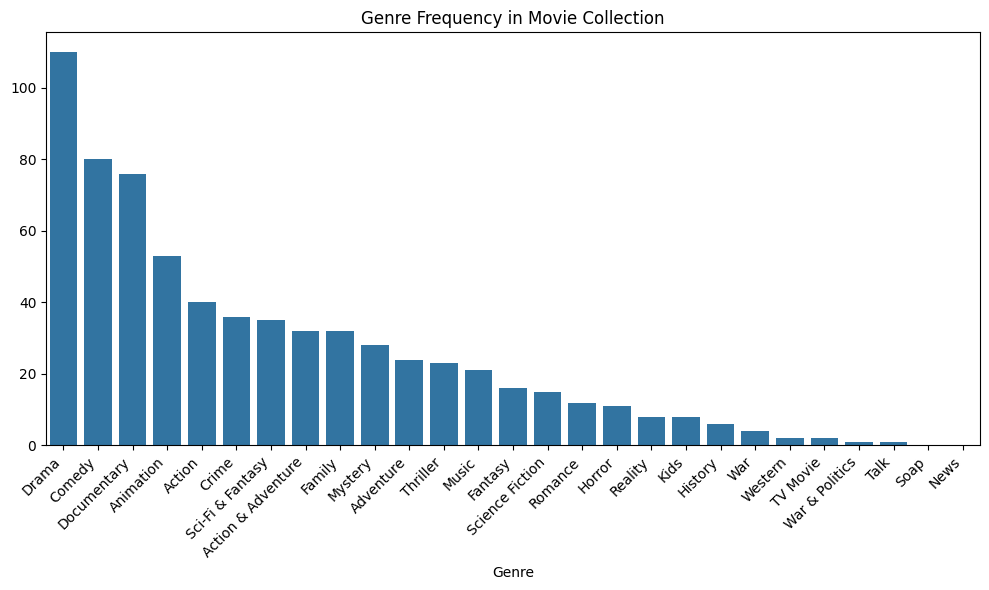

In [7]:
# Plot count of genres in the dataset
plt.figure(figsize=(10, 6))
genre_counts = merged_data[all_genres].sum().sort_values(ascending=False)
sns.barplot(x=genre_counts.index, y=genre_counts.values)
plt.title('Genre Frequency in Movie Collection')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Genre')
plt.tight_layout()
plt.show()

This bar chart displays the frequency distribution of genres across a movie collection, with Drama being the most prevalent genre, followed by Comedy and Documentary.

Text(0, 0.5, '3-Day Abnormal Return (%)')

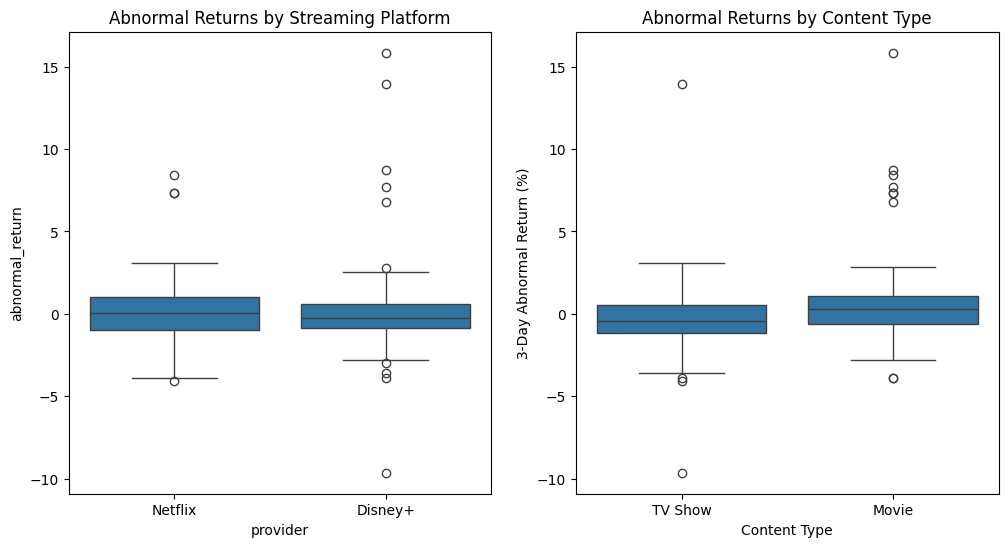

In [ ]:
n_rows = 1
n_cols = 2
# Boxplot of Abnormal Returns by Streaming Platform
plt.figure(figsize=(12, 6))
plt.subplot(n_rows, n_cols, 1)
sns.boxplot(x='provider', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Streaming Platform')

# Boxplot of Abnormal Returns by Content Type
plt.subplot(n_rows, n_cols, 2)
sns.boxplot(x='content-type', y='abnormal_return', data=merged_data)
plt.title('Abnormal Returns by Content Type')
plt.xlabel('Content Type')
plt.ylabel('3-Day Abnormal Return (%)')


The boxplots compare 3-day abnormal stock returns after content releases. Both Netflix and Disney+ show median returns near zero, though Disney+ has more extreme outliers. Similarly, TV shows and movies have comparable median returns, but movies display more positive outliers. Overall, most content releases have minimal stock price impact, though occasional releases trigger significant market reactions regardless of platform or content type.